In [2]:
!pip install yfinance pandas numpy matplotlib seaborn


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')



In [12]:
data = yf.download('RELIANCE.NS', start='2022-01-01', end='2025-01-01')
data.head()

C:\Users\henis\AppData\Local\Temp\ipykernel_13476\2143269857.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('RELIANCE.NS', start='2022-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2022-01-03,1093.780518,1095.646128,1075.443589,1076.103370,5421611
2022-01-04,1118.465088,1119.784652,1093.848914,1099.263652,10847728
2022-01-05,1123.697632,1127.064782,1107.021470,1120.239614,11643813
2022-01-06,1099.536499,1116.599479,1096.123855,1115.325409,14447422
2022-01-07,1108.409302,1118.442271,1097.284238,1106.111499,13112115


In [13]:
print("Data Summary:")
print(data.describe())

print("\nData Columns:")
print(data.columns)


Data Summary:
Price         Close         High          Low         Open        Volume
Ticker  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   RELIANCE.NS
count    739.000000   739.000000   739.000000   739.000000  7.390000e+02
mean    1240.003438  1251.688828  1229.029290  1240.456373  1.351479e+07
std      142.881902   144.037423   141.913233   142.983259  7.056946e+06
min     1004.863220  1013.422547   991.926175  1006.259040  2.127335e+06
25%     1131.860596  1142.914371  1122.075599  1131.215073  9.045548e+06
50%     1194.657715  1204.671737  1182.348971  1194.651701  1.199947e+07
75%     1349.298645  1362.326541  1335.130078  1348.153874  1.625930e+07
max     1589.138062  1596.980044  1573.851280  1592.662006  8.199715e+07

Data Columns:
MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])


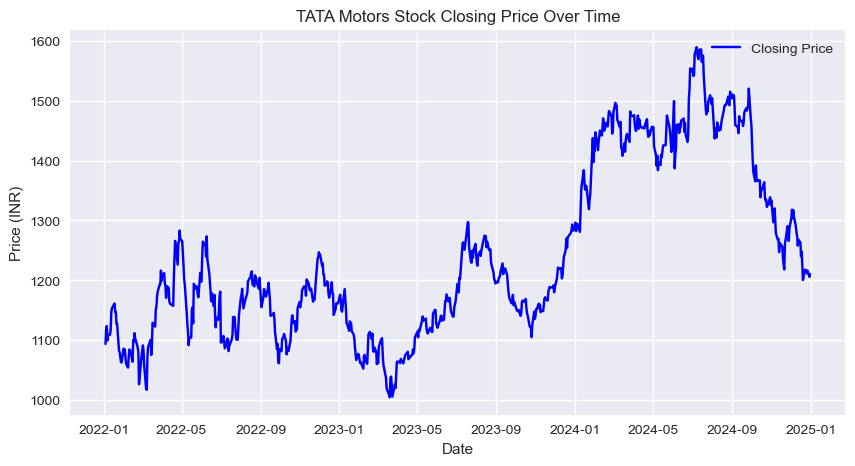

In [14]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Closing Price', color='blue')
plt.title('TATA Motors Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()


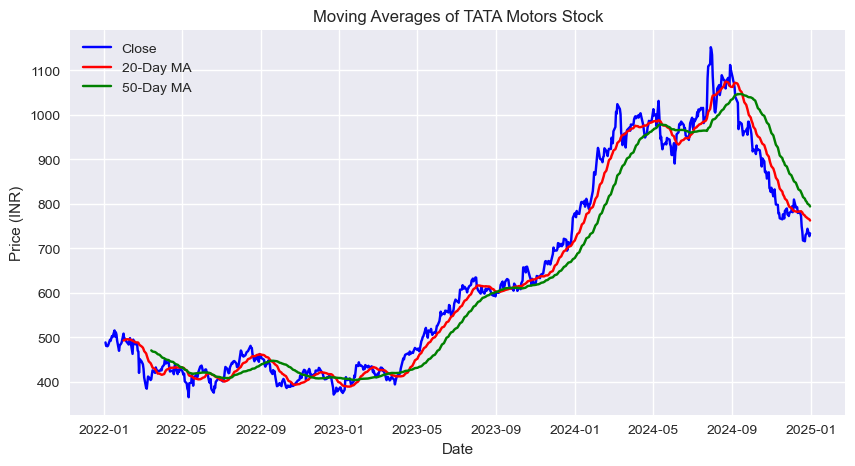

In [22]:
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()

# Plot
plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Close', color='blue')
plt.plot(data['MA20'], label='20-Day MA', color='red')
plt.plot(data['MA50'], label='50-Day MA', color='green')
plt.title('Moving Averages of TATA Motors Stock')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()


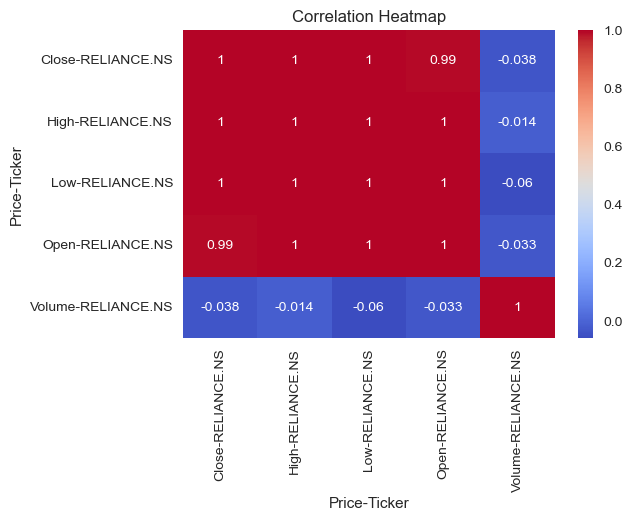

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


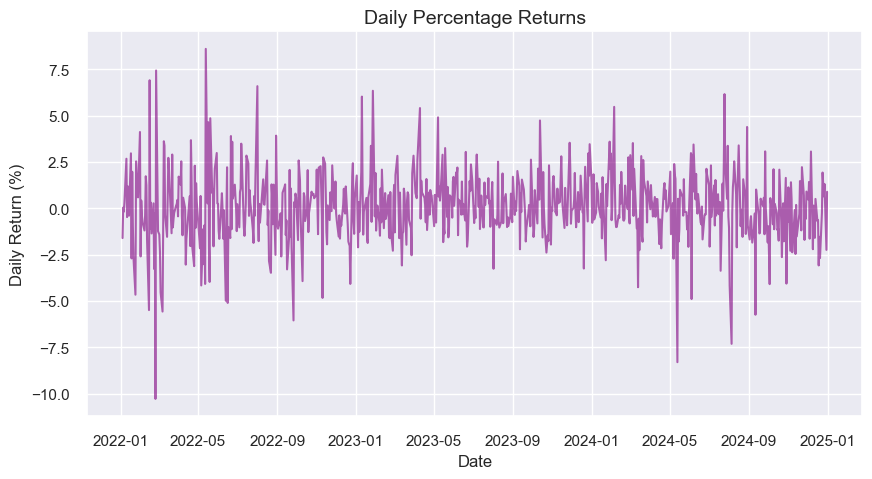

Price,Close,Daily_Return
Ticker,TATAMOTORS.NS,
Date,,
2024-12-24,729.825073,1.924673
2024-12-26,734.484985,0.638497
2024-12-27,744.102356,1.309403
2024-12-30,727.395996,-2.245170
2024-12-31,733.840576,0.885980


In [37]:
data['Daily_Return'] = data['Close'].pct_change() * 100
plt.figure(figsize=(10,5))
plt.plot(data['Daily_Return'], color='purple', alpha=0.6)
plt.title('Daily Percentage Returns', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.show()

data[['Close', 'Daily_Return']].tail()


In [ ]:
data['Cumulative_Return'] = (1 + data['Daily_Return']/100).cumprod()
plt.figure(figsize=(10,5))
plt.plot(data['Cumulative_Return'], color='orange')
plt.title('Cumulative Returns Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Growth Multiplier')
plt.show()
